# XGBoost Full Dataset Visualisation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('outputs/xgboost_final_dataset.csv')

gender_ind = ["female_married_by_18", "female_married_by_15", "marriage_gap_18", "anc4_15_19_pct", "modern_contraceptive_pct"]
wash_ind = ["wat_bas_nat", "san_bas_nat", "hyg_bas_nat"]
edu_ind = ["completion_primary_f", "literacy_f"]
health_ind = ["diarrhoea_care_pct", "pneumonia_care_pct", "itn_use_pct", "exclusive_bf_pct", "low_birthweight_pct"]

all_indicators = gender_ind + wash_ind + edu_ind + health_ind

indicator_labels = {
    "female_married_by_18": "Child Marriage by 18 (%)",
    "female_married_by_15": "Child Marriage by 15 (%)",
    "marriage_gap_18": "Marriage Gender Gap",
    "anc4_15_19_pct": "Antenatal Care 4+ (%)",
    "modern_contraceptive_pct": "Modern Contraceptives (%)",
    "wat_bas_nat": "Basic Water (%)",
    "san_bas_nat": "Basic Sanitation (%)",
    "hyg_bas_nat": "Basic Hygiene (%)",
    "completion_primary_f": "Female Primary Completion (%)",
    "literacy_f": "Female Literacy (%)",
    "diarrhoea_care_pct": "Diarrhoea Treatment (%)",
    "pneumonia_care_pct": "Pneumonia Care Seeking (%)",
    "itn_use_pct": "ITN Bednet Use (%)",
    "exclusive_bf_pct": "Exclusive Breastfeeding (%)",
    "low_birthweight_pct": "Low Birthweight (%)"
}

print(f"Loaded dataset with {len(df)} countries and {len(all_indicators)} predictors.")

Loaded dataset with 163 countries and 15 predictors.


## 1. Missing Data Analysis

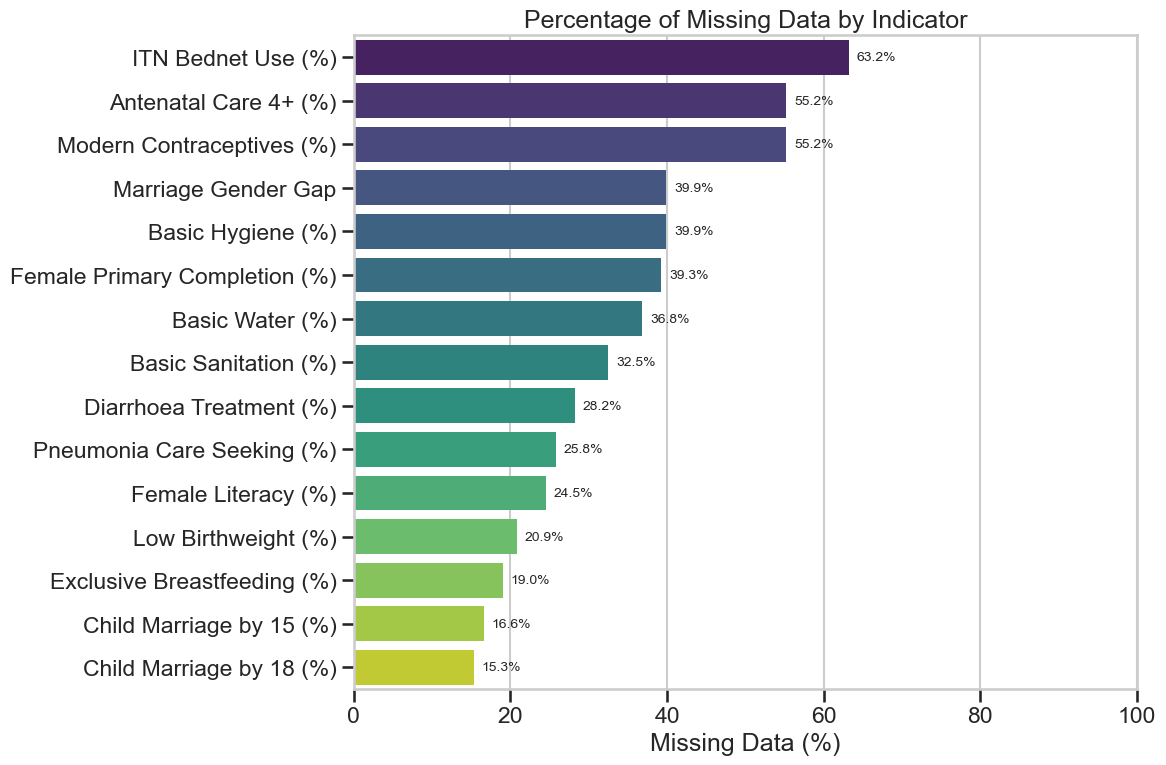

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

plt.figure(figsize=(12, 8))
missing_data = df[all_indicators].isna().mean() * 100
missing_data = missing_data.sort_values(ascending=False)

ax = sns.barplot(x=missing_data.values, y=[indicator_labels[k] for k in missing_data.index], hue=missing_data.index, legend=False, palette='viridis')
plt.title('Percentage of Missing Data by Indicator')
plt.xlabel('Missing Data (%)')
plt.xlim(0, 100)

for i, v in enumerate(missing_data.values):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)
    
plt.tight_layout()
plt.show()

## 2. Distributions of All Predictors

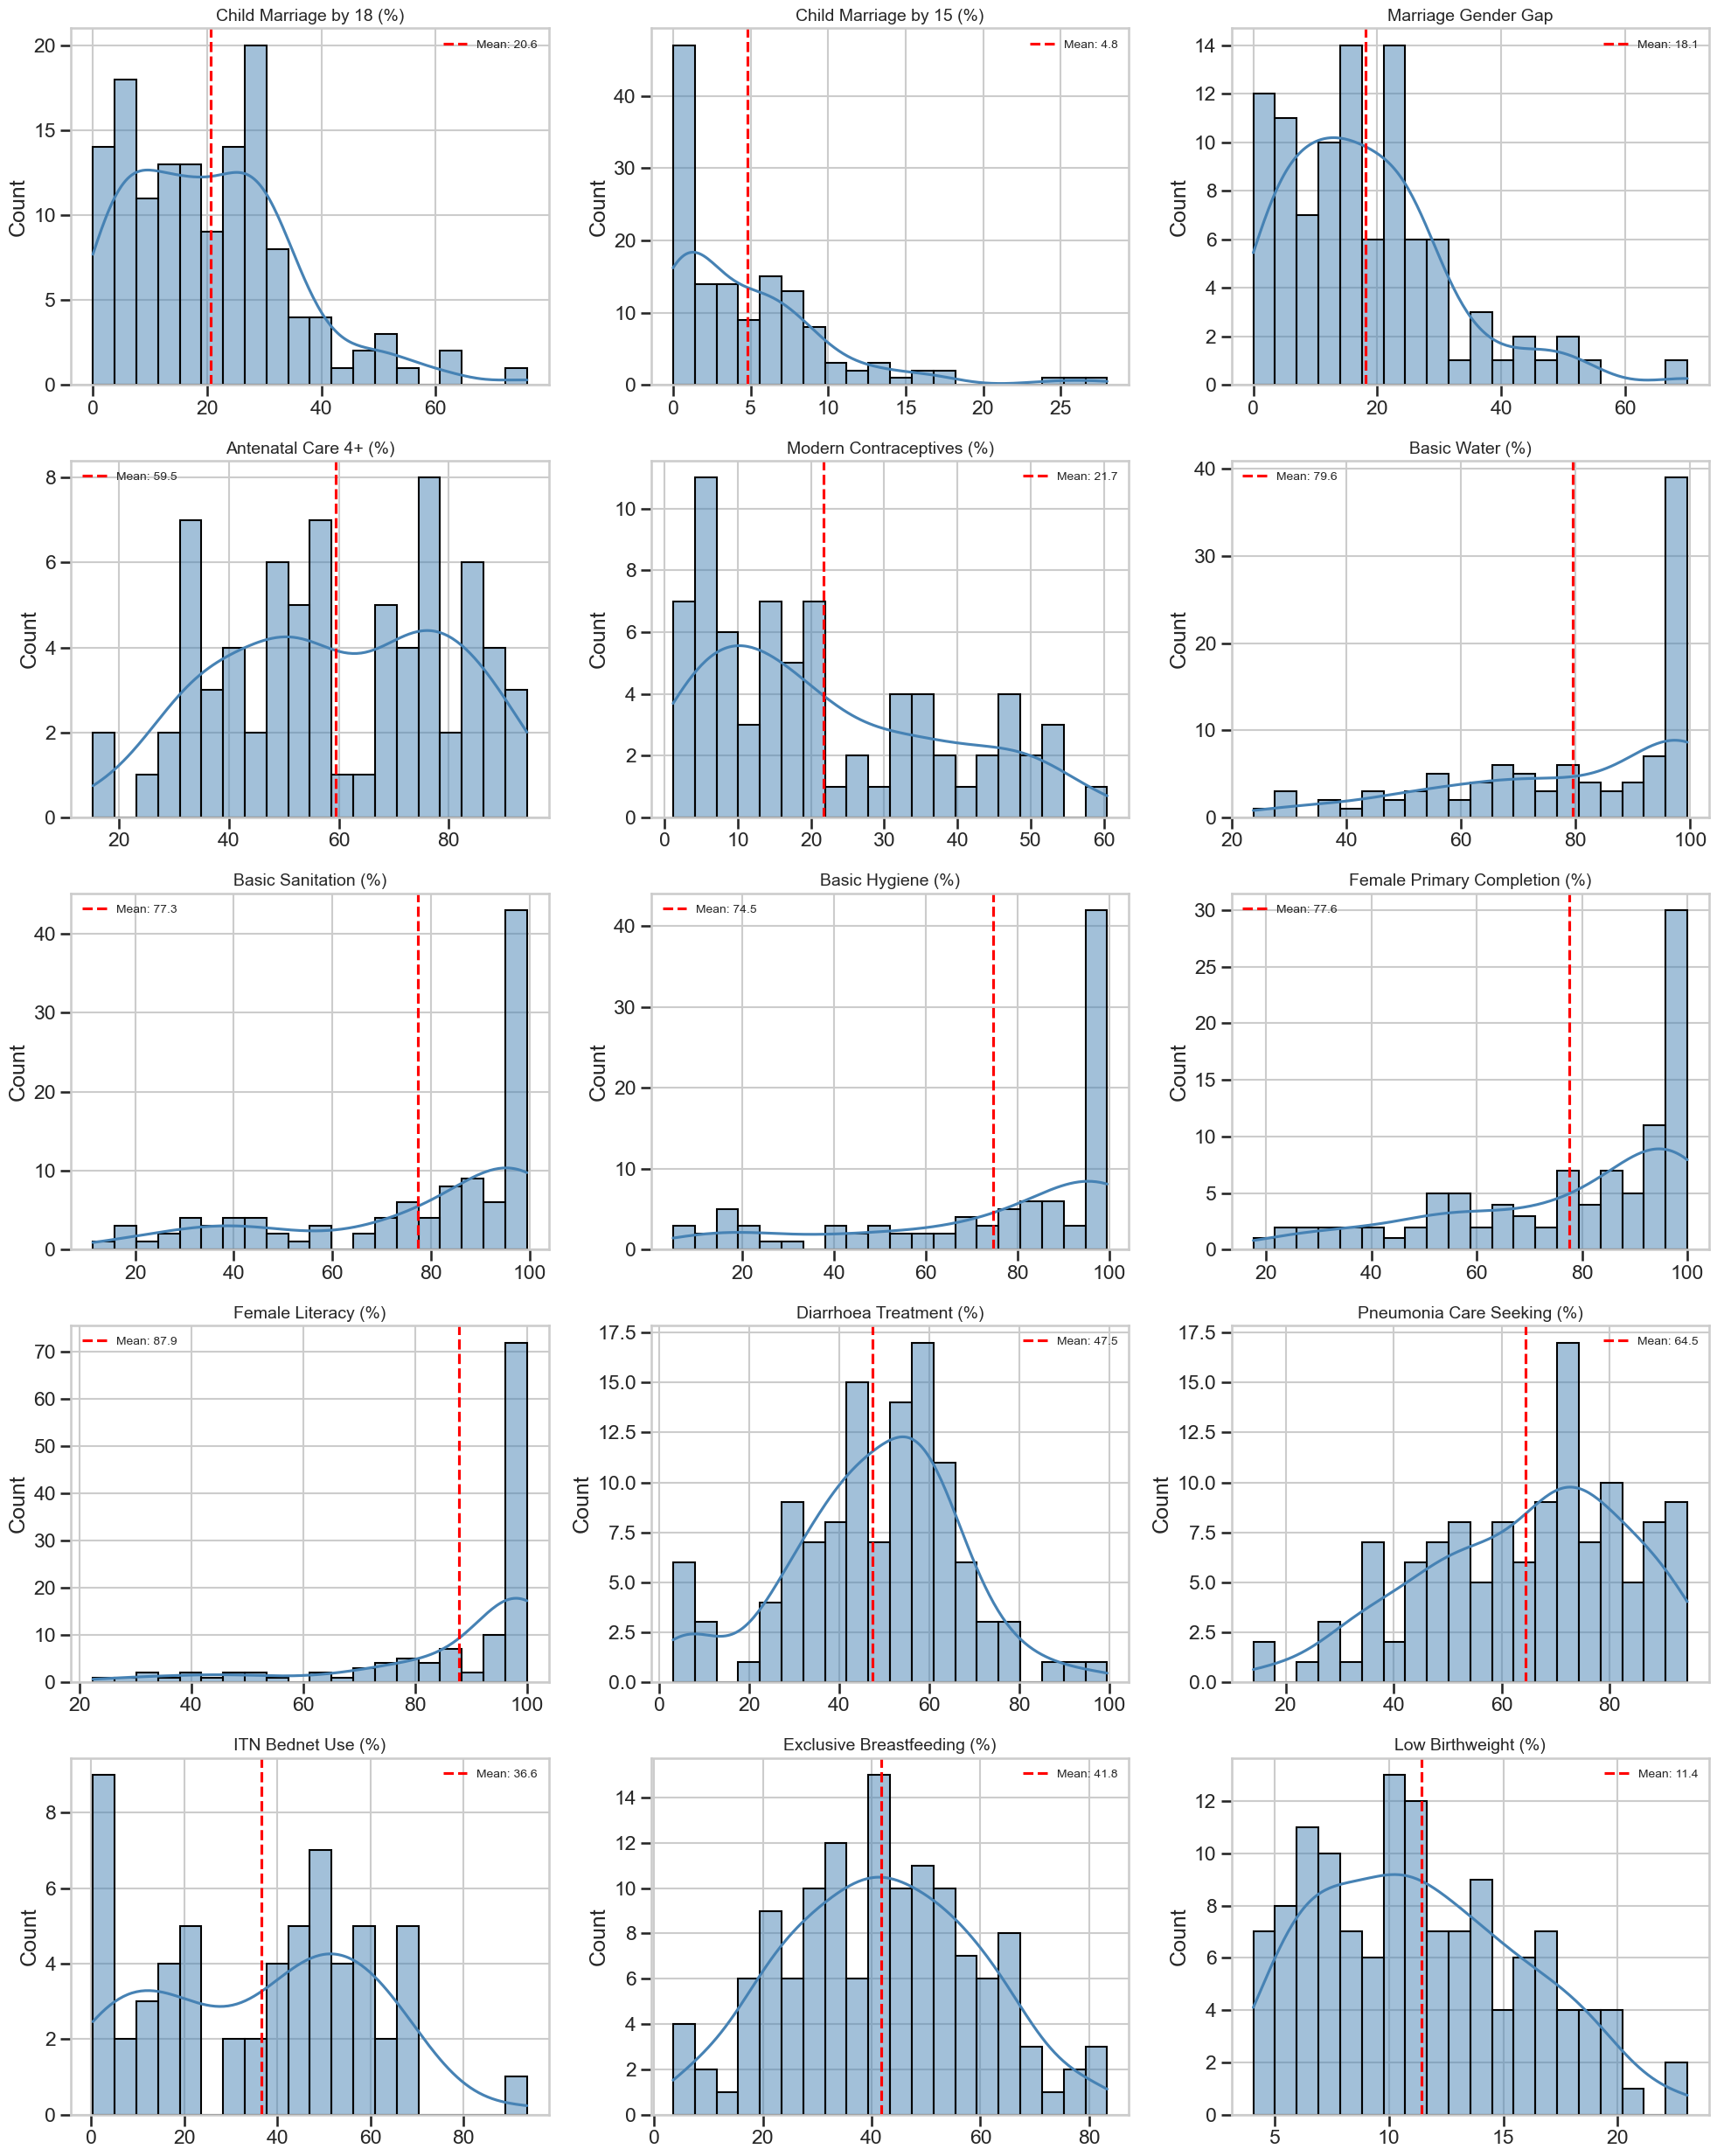

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(20, 25))
axes = axes.flatten()

for i, indicator in enumerate(all_indicators):
    sns.histplot(data=df, x=indicator, kde=True, ax=axes[i], color='steelblue', bins=20)
    axes[i].set_title(f'{indicator_labels[indicator]}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    
    mean_val = df[indicator].mean()
    if pd.notna(mean_val):
        axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
        axes[i].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 3. Correlation with Malnutrition

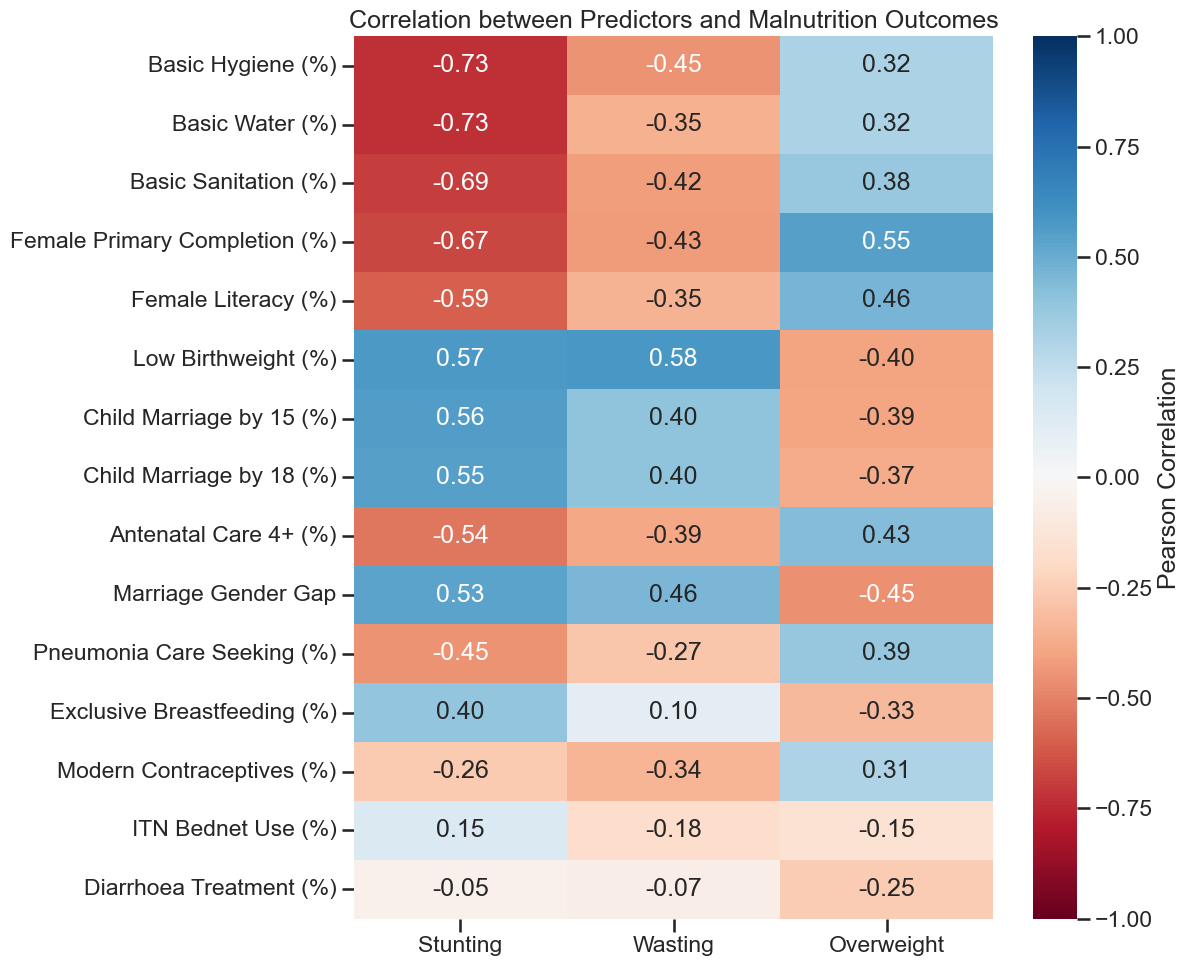

In [ ]:
targets = ['stunting_national', 'wasting_national', 'overweight_national']
target_labels = ['Stunting', 'Wasting', 'Overweight']

cols = targets + all_indicators
corr_df = df[cols].corr()

target_corr = corr_df.loc[all_indicators, targets]

target_corr.index = [indicator_labels[i] for i in target_corr.index]
target_corr.columns = target_labels

target_corr = target_corr.reindex(target_corr['Stunting'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 10))
sns.heatmap(target_corr, annot=True, cmap='RdBu', center=0, vmin=-1, vmax=1, fmt='.2f', cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation between Predictors and Malnutrition Outcomes')
plt.tight_layout()
plt.show()

## 4. Pairwise Relationships

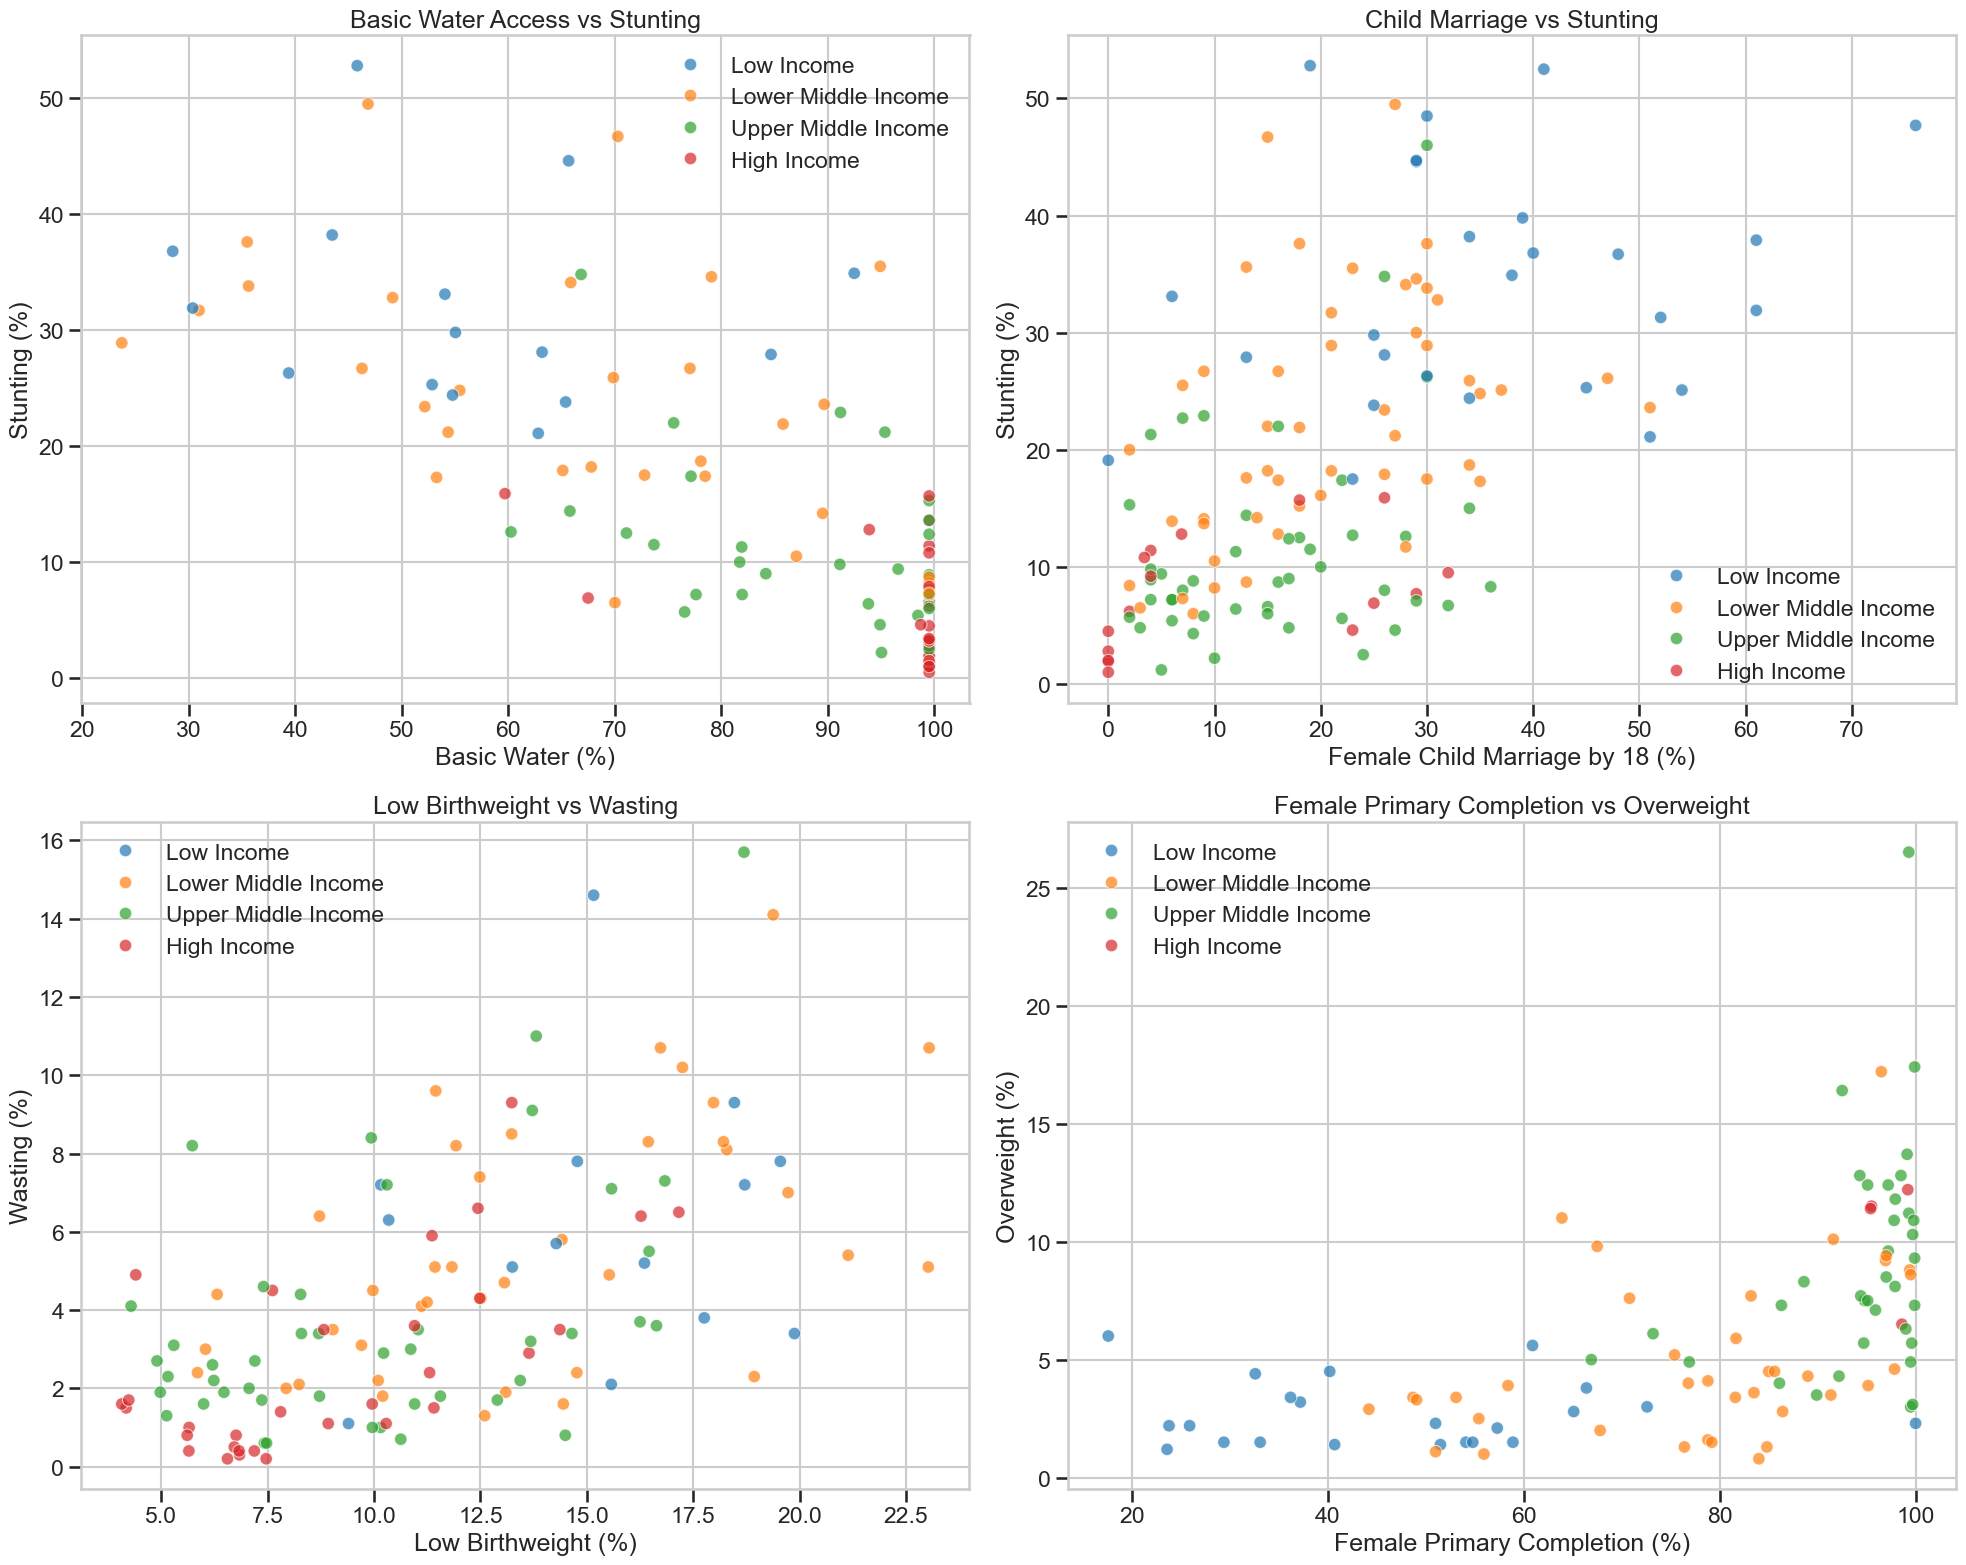

In [ ]:
income_order = ['Low Income', 'Lower Middle Income', 'Upper Middle Income', 'High Income']

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

sns.scatterplot(data=df, x='wat_bas_nat', y='stunting_national', 
                hue='income_group', hue_order=income_order, 
                alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title('Basic Water Access vs Stunting')
axes[0, 0].set_xlabel('Basic Water (%)')
axes[0, 0].set_ylabel('Stunting (%)')

sns.scatterplot(data=df, x='female_married_by_18', y='stunting_national', 
                hue='income_group', hue_order=income_order, 
                alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title('Child Marriage vs Stunting')
axes[0, 1].set_xlabel('Female Child Marriage by 18 (%)')
axes[0, 1].set_ylabel('Stunting (%)')

sns.scatterplot(data=df, x='low_birthweight_pct', y='wasting_national', 
                hue='income_group', hue_order=income_order, 
                alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Low Birthweight vs Wasting')
axes[1, 0].set_xlabel('Low Birthweight (%)')
axes[1, 0].set_ylabel('Wasting (%)')

sns.scatterplot(data=df, x='completion_primary_f', y='overweight_national', 
                hue='income_group', hue_order=income_order, 
                alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Female Primary Completion vs Overweight')
axes[1, 1].set_xlabel('Female Primary Completion (%)')
axes[1, 1].set_ylabel('Overweight (%)')

for ax in axes.flatten():
    leg = ax.get_legend()
    if leg:
        leg.set_title(None)

plt.tight_layout()
plt.show()